# Debugging: recording singing

In [1]:
# import sounddevice as sd
# import soundfile as sf
# from scipy.io import wavfile
# import os
# duration_recording = 5
# SAMPLE_RATE = 44100


# def save_samples_to_file(samples, filename, fs):
#     wavfile.write(filename, rate=fs, data=samples.astype(np.float32))

    
# print("SING THE MELODY ")
# myrecording = sd.rec(int((duration_recording ) *  SAMPLE_RATE), samplerate=  SAMPLE_RATE, channels=1)
# status = sd.wait()

# # save recording to wav
# save_samples_to_file(
#     myrecording,
#     os.path.join(output_dir,recording_file),
#     SAMPLE_RATE)

# print("Finished")

# Debugging: reading data

In [2]:
# Before starting, set the right working dir and imports
import os
if 'path_to_dir' not in globals():
    path_to_dir = os.path.split(os.getcwd())[0]
os.chdir(path_to_dir)

# imports
import numpy as np
import shutil
import matplotlib.pyplot as plt
%matplotlib inline

from sing4me import singing_extract as sing
from sing_experiments import melodies, params

ModuleNotFoundError: No module named 'textgrid'

In [3]:
# Global parameters
config = params.singing_2intervals
print(config["reference_mode"])
# Indicate your gender
GENDER = "male" # or "female"

# try paarameters for rhythm experiments
#config["cut_pre"] = 30
#config["cut_post"] = 50
config["msec_silence"] = 70
config["db_threshold"]=  -22
config["db_end_threshold_realtive_2note_start"]=  -10
config["max_vs_start_threshold_importance"]=  0.9
config["minimal_segment_duration"] = 70


pitch_mode


## Analyse

In [4]:
# import recordings
# recording_file='KeyError_Analysis1.wav'
# recording_file='audio_demo_debug.wav'
recording_file='3f87ec55-cb00-4350-922b-47513c754a83.wav'
#recording_file='463f361c-e4d6-4fab-82b6-255a8b9bb0e8.wav'

plot_file_name = f"plot_{recording_file}.png"

target_pitches = [50, 50, 50, 50, 50]
reference_pitch = 50

In [5]:
# analyse
import tempfile
import parselmouth

def recode_wav(file_path):
    with tempfile.NamedTemporaryFile() as temp_file:
        shutil.copyfile(file_path, temp_file.name)
        s = parselmouth.Sound(temp_file.name)
        s.save(file_path, "WAV")

recode_wav(os.path.join("input/rhythm", recording_file))

In [6]:
# compute sung pitches and intervals5
raw = sing.analyze(
    os.path.join("input/rhythm",recording_file),
    config,
    target_pitches=target_pitches,
    plot_options=sing.PlotOptions(
        save=True,
        path= os.path.join("output", plot_file_name),
        format="png"
    ),
)

raw = [{key: melodies.as_native_type(value) for key, value in x.items()} for x in raw]
sung_pitches = [x["median_f0"] for x in raw]
sung_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
            sung_pitches,
             "previous_note"
        )

target_intervals = melodies.convert_absolute_pitches_to_interval_sequence(
    target_pitches,
    "previous_note"
)
pitch_heights = melodies.convert_absolute_pitches_to_pitch_heights(
    sung_pitches,
    reference_pitch
)
stats = sing.compute_stats(
    sung_pitches,
    target_pitches,
    sung_intervals,
    target_intervals
)
print(f"sung pitches: {sung_pitches}")
print(f"target pitches: {target_pitches}")
print(f"sung intervals: {sung_intervals}")
print(f"target intervals: {target_intervals}")
print(f"pitch heights: {pitch_heights}")


print(f"stats: {stats}")

Plot saved
sung pitches: [56.12809919088393, 52.98181496163358, 50.126180528626094, 43.549447142249235, 44.906385872086645]
target pitches: [50, 50, 50, 50, 50]
sung intervals: [-3.146284229250348, -2.855634433007488, -6.5767333863768584, 1.3569387298374096]
target intervals: [0, 0, 0, 0]
pitch heights: [6.12809919088393, 2.9818149616335816, 0.12618052862609375, 6.450552857750765, 5.093614127913355]
stats: {'num_sung_pitches': 5, 'num_target_pitches': 5, 'raw_pitch_diffs': [6.12809919088393, 2.9818149616335816, 0.12618052862609375, -6.450552857750765, -5.093614127913355], 'mean_pitch_diffs': -0.46161446090410296, 'max_abs_pitch_error': 6.450552857750765, 'root_mean_squared_pitch': 4.775254521787369, 'raw_interval_diffs': [-3.146284229250348, -2.855634433007488, -6.5767333863768584, 1.3569387298374096], 'mean_interval_diff': -2.805428329699321, 'max_abs_interval_error': 6.5767333863768584, 'root_mean_squared_interval': 3.973300178007705, 'direction_accuracy': 0.0}


In [7]:
is_failed = melodies.failing_criteria(
    sung_intervals,
    sung_pitches,
    reference_pitch,
    config["num_int"],
    config["max_interval_size"],
    config["max_melody_pitch_range"],
    config["reference_mode"],
    stats,
    config["max_abs_interval_error_treshold"],
    config["max_pitch_height"]
)
print(f"Failing Criteria: {is_failed}")

Failing Criteria: {'failed': False, 'reason': 'All good'}


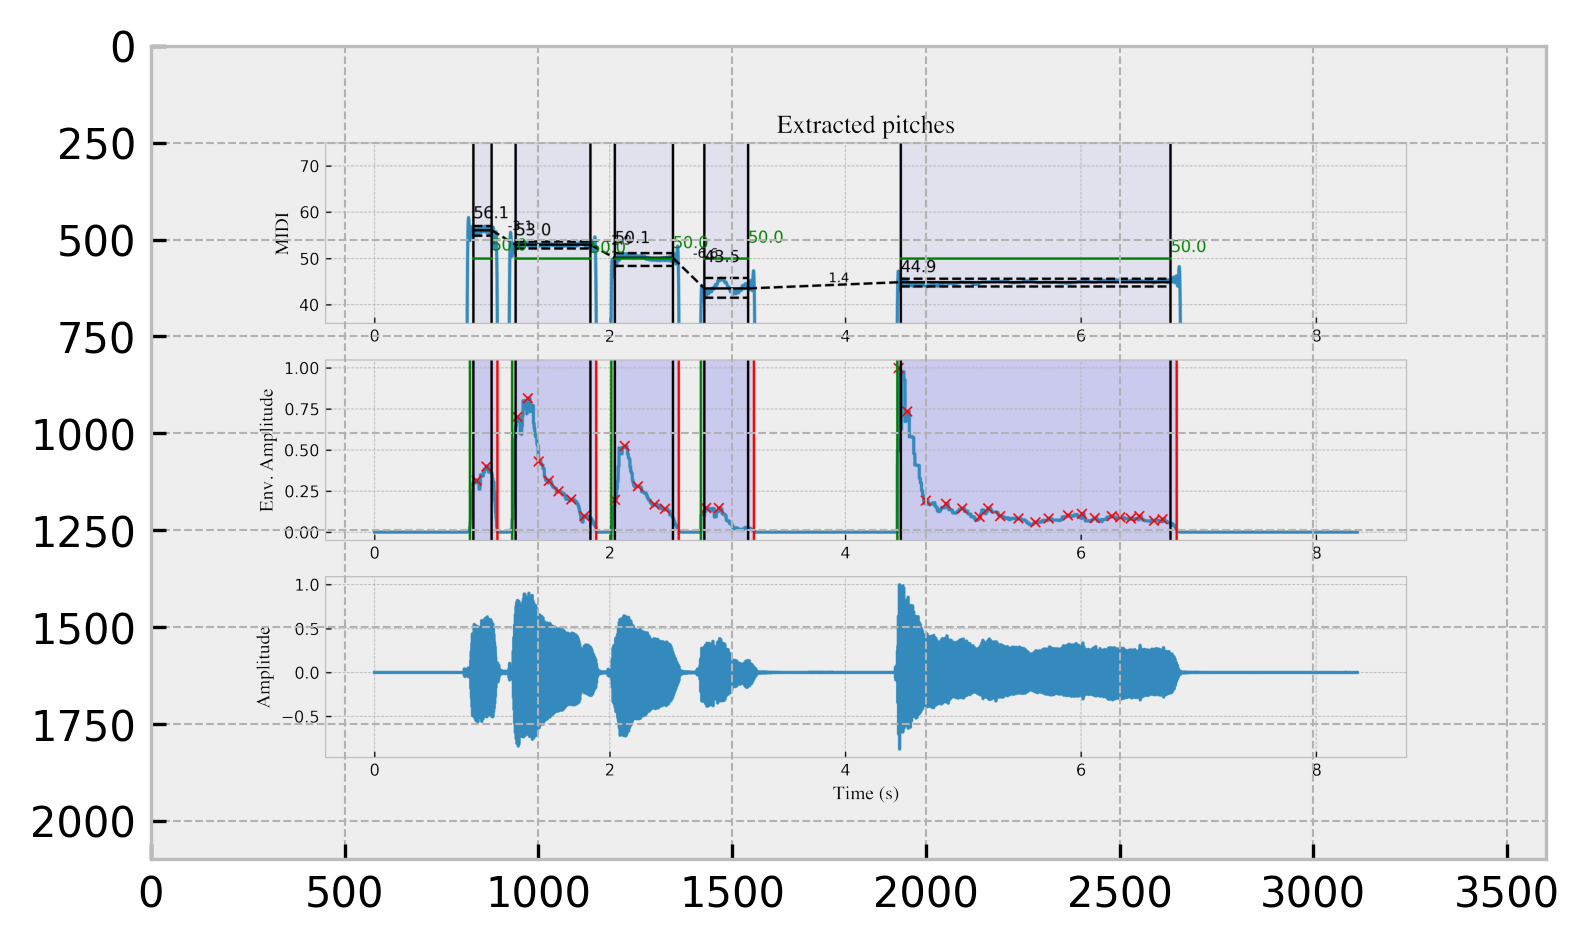

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
path= os.path.join("output", plot_file_name)
img = mpimg.imread(path)
imgplot = plt.imshow(img)
plt.gcf().set_dpi(300)
plt.show()


# 